<a href="https://colab.research.google.com/github/ZachSkiba/CSP571-G7/blob/main/data/raw/Data_Preparation_and_Analysis_571_Diabetes_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================
# DATA OVERVIEW
# ============================
# This dataset contains health, lifestyle, and demographic information
# for over 250,000 individuals.
#
# The target variable (Diabetes_binary) indicates whether a person
# has diabetes or prediabetes (1) or not (0).
#
# All variables are numeric and there are no missing values,
# so minimal data cleaning is required.

In [ ]:
!pip install -U ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [ ]:
# ============================
# DATA CLEANING
# ============================
# The dataset is already clean with no missing values.
# We remove duplicates and ensure data is properly formatted
# before moving into analysis and modeling.

In [ ]:
X.head()
y.head()

df = X.copy()
df["Diabetes_binary"] = y

df.head()
df.shape
df.info()
df.describe()
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

In [ ]:
# ============================
# TARGET DISTRIBUTION
# ============================
# We examine how many individuals have diabetes vs not.
# This helps identify class imbalance, which is important
# for model performance and evaluation.

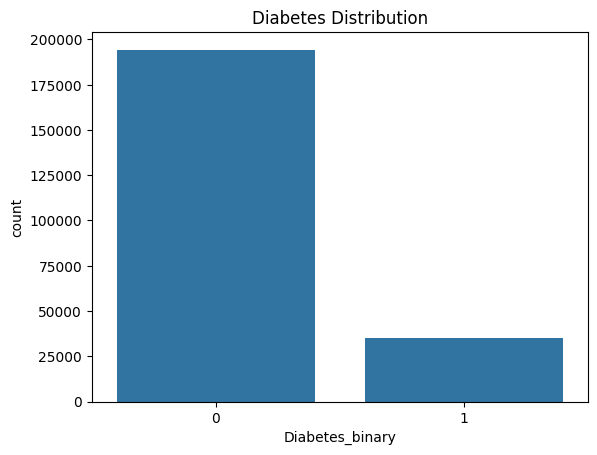

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Diabetes_binary", data=df)
plt.title("Diabetes Distribution")
plt.show()

In [ ]:
# ============================
# CORRELATION ANALYSIS
# ============================
# This section identifies which features are most related
# to diabetes. Strong correlations suggest potential
# risk factors and important predictors.

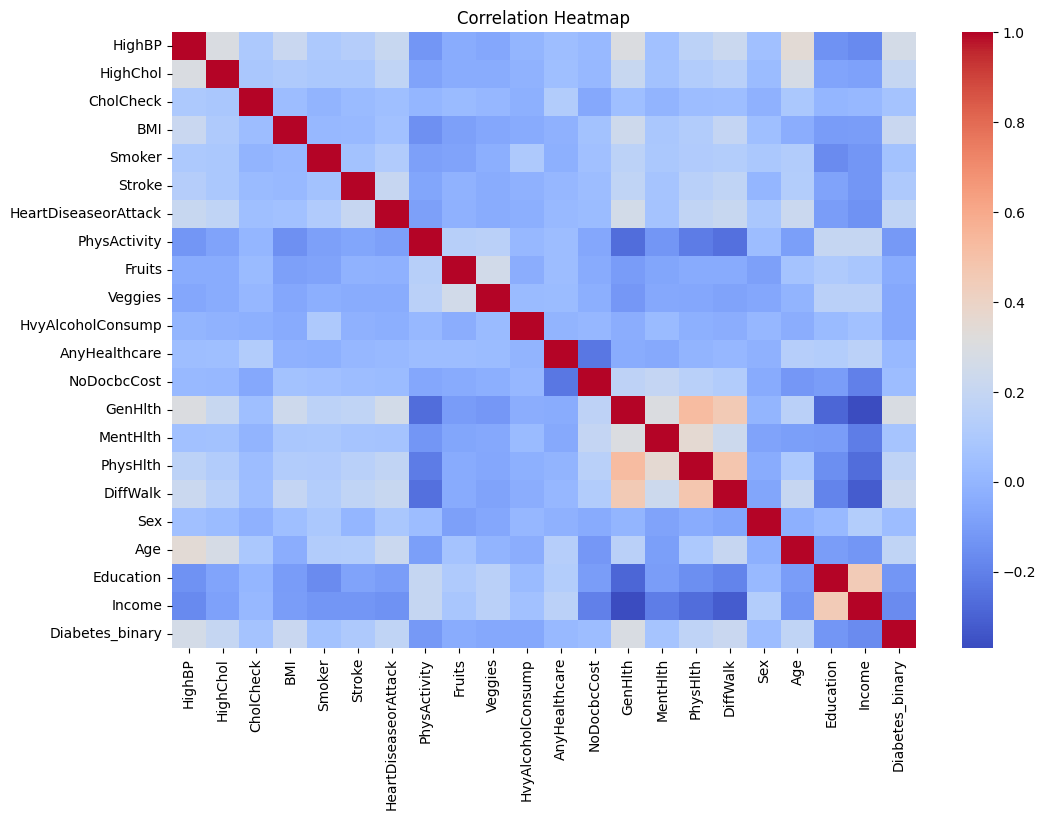

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ============================
# HEALTH FACTORS ANALYSIS
# ============================
# We analyze medical indicators such as BMI, blood pressure,
# and cholesterol to see how they relate to diabetes risk.

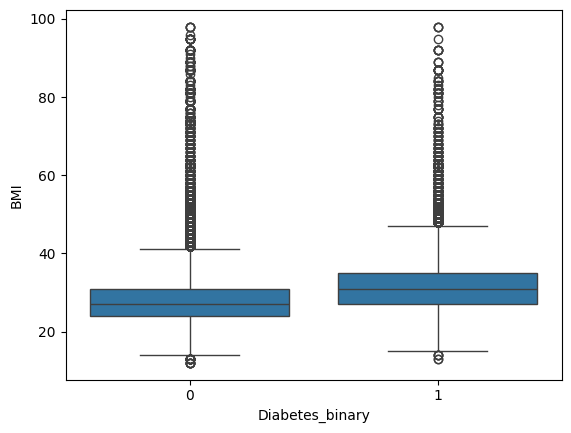

In [ ]:
sns.boxplot(x="Diabetes_binary", y="BMI", data=df)
plt.show()

In [ ]:
# ============================
# LIFESTYLE ANALYSIS
# ============================
# This section explores how behaviors such as physical activity,
# diet, and smoking impact diabetes outcomes.

In [ ]:
df.groupby("NoDocbcCost")["Diabetes_binary"].mean()

,Diabetes_binary
NoDocbcCost,
0,0.136033
1,0.175236


In [ ]:
# ============================
# HEALTHCARE ACCESS ANALYSIS
# ============================
# These variables help us understand how access to healthcare
# (insurance, cost barriers) affects diabetes prevalence.
# This is important for identifying systemic health disparities.

In [ ]:
df.groupby("Income")["Diabetes_binary"].mean()

,Diabetes_binary
Income,
1,0.242891
2,0.261903
3,0.223084
4,0.201341
5,0.174014
6,0.145078
7,0.121821
8,0.079604


In [ ]:
df["Diabetes_binary"].value_counts(normalize=True)

,proportion
Diabetes_binary,
0,0.860667
1,0.139333


In [ ]:
df.corr()["Diabetes_binary"].sort_values(ascending=False)

,Diabetes_binary
Diabetes_binary,1.000000
GenHlth,0.293569
HighBP,0.263129
DiffWalk,0.218344
BMI,0.216843
HighChol,0.200276
Age,0.177442
HeartDiseaseorAttack,0.177282
PhysHlth,0.171337
Stroke,0.105816


In [ ]:
df.groupby("HighBP")["Diabetes_binary"].mean()
df.groupby("BMI")["Diabetes_binary"].mean()
df.groupby("PhysActivity")["Diabetes_binary"].mean()
df.groupby("Income")["Diabetes_binary"].mean()

,Diabetes_binary
Income,
1,0.242891
2,0.261903
3,0.223084
4,0.201341
5,0.174014
6,0.145078
7,0.121821
8,0.079604


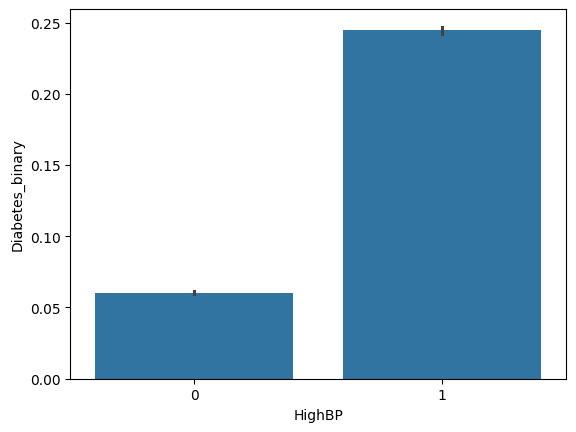

In [ ]:
sns.barplot(x="HighBP", y="Diabetes_binary", data=df)
plt.show()